<a href="https://colab.research.google.com/github/MdRimon29/borno-lm/blob/main/src/pretraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the tokenizer dependency.
!pip install -q sentencepiece

In [2]:
# Install the Hugging Face datasets library.
!pip install -q datasets

In [3]:
# Mount Google Drive so checkpoints persist after the Colab session ends.
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Import the libraries required for pretraining.
import math
import random
from pathlib import Path

import numpy as np
import sentencepiece as spm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [5]:
# Set random seeds and select the available training device.
def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

set_seed(123)

print("Device:", device)

Device: cuda


In [6]:
# Create the Borno-LM directories on Google Drive.
ROOT_DIR = Path("/content/drive/MyDrive/borno-lm")

DATA_DIR = ROOT_DIR / "data"
CHECKPOINT_DIR = ROOT_DIR / "checkpoints"
TOKENIZER_DIR = ROOT_DIR / "tokenizer"

for path in [DATA_DIR, CHECKPOINT_DIR, TOKENIZER_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(ROOT_DIR)

/content/drive/MyDrive/borno-lm


In [7]:
# Load a small Bangla subset from the Hugging Face corpus.
from datasets import load_dataset

dataset = load_dataset(
    "ahmed-farhanur-rashid/bn-foundational-pretrain-corpus",
    "bangla_corpus",
    split="train",
    streaming=True,
)

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

In [8]:
# Collect a manageable Bangla corpus for the first pretraining experiment.
TARGET_CHARS = 2_000_000

texts = []
total_chars = 0

for sample in dataset:
    text_sample = sample["text"]

    if not text_sample:
        continue

    texts.append(text_sample)
    total_chars += len(text_sample)

    if total_chars >= TARGET_CHARS:
        break

text = "\n\n".join(texts)

print(f"Documents: {len(texts):,}")
print(f"Characters: {len(text):,}")
print(text[:1000])

Documents: 131
Characters: 2,006,153
<|lang_bn|>বাংলা ভাষা (বাঙলা, বাঙ্গলা, তথা বাঙ্গালা নামেও পরিচিত) একটি ইন্দো-আর্য ভাষা, যা দক্ষিণ এশিয়ার বাঙালি জাতির প্রধান কথ্য ও লেখ্য ভাষা। মাতৃভাষীর সংখ্যায় বাংলা ইন্দো-ইউরোপীয় ভাষা পরিবারের পঞ্চম ও মোট ব্যবহারকারীর সংখ্যা অনুসারে বাংলা বিশ্বের ষষ্ঠ বৃহত্তম ভাষা। বাংলা সার্বভৌম ভাষাভিত্তিক জাতিরাষ্ট্র বাংলাদেশের একমাত্র রাষ্ট্রভাষা তথা সরকারি ভাষা এবং ভারতের পশ্চিমবঙ্গ, ত্রিপুরা, আসামের বরাক উপত্যকার সরকারি ভাষা। বঙ্গোপসাগরে অবস্থিত আন্দামান দ্বীপপুঞ্জের প্রধান কথ্য ভাষা বাংলা। এছাড়া ভারতের ঝাড়খণ্ড, বিহার, মেঘালয়, মিজোরাম,  ওড়িশা রাজ্যগুলোতে উল্লেখযোগ্য পরিমাণে বাংলাভাষী জনগণ রয়েছে। ২০১১ সালের আদমশুমারি অনুযায়ী, ভারতের মোট জনসংখ্যার ৮.০৩ শতাংশ মানুষ বাংলা ভাষায় কথা বলে এবং হিন্দির পরেই ভারতে সর্বাধিক প্রচলিত ভাষা - বাংলা। এছাড়াও মধ্য প্রাচ্য, আমেরিকা ও ইউরোপে উল্লেখযোগ্য পরিমাণে বাংলাভাষী অভিবাসী রয়েছে। সারা বিশ্বে সব মিলিয়ে ২৭.৬ কোটির অধিক লোক দৈনন্দিন জীবনে বাংলা ব্যবহার করে। বাংলাদেশের জাতীয় সঙ্গীত এবং ভারতের জাতীয় সঙ্গীত ও স্তোত্র বাংলাতে র

In [9]:
# Split the corpus into training and validation text.
split_idx = int(len(text) * 0.9)

train_text = text[:split_idx]
val_text = text[split_idx:]

print(f"Train characters: {len(train_text):,}")
print(f"Validation characters: {len(val_text):,}")

Train characters: 1,805,537
Validation characters: 200,616


In [10]:
# Save the collected Bangla corpus and define its path.
DATA_PATH = DATA_DIR / "bangla_corpus.txt"

DATA_PATH.write_text(text, encoding="utf-8")

print(f"Dataset saved: {DATA_PATH}")
print(f"File exists: {DATA_PATH.exists()}")

Dataset saved: /content/drive/MyDrive/borno-lm/data/bangla_corpus.txt
File exists: True


In [11]:
# Train a 16K SentencePiece BPE tokenizer for Bangla.
TOKENIZER_PREFIX = TOKENIZER_DIR / "borno_bpe"
TOKENIZER_MODEL = TOKENIZER_DIR / "borno_bpe.model"

if not TOKENIZER_MODEL.exists():
    spm.SentencePieceTrainer.train(
        input=str(DATA_PATH),
        model_prefix=str(TOKENIZER_PREFIX),
        vocab_size=16_000,
        model_type="bpe",
        character_coverage=0.9995,
        normalization_rule_name="nmt_nfkc",
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
    )

print("Tokenizer:", TOKENIZER_MODEL)

Tokenizer: /content/drive/MyDrive/borno-lm/tokenizer/borno_bpe.model


In [12]:
# Define the tokenizer used by Borno-LM.
class BornoTokenizer:

    def __init__(self, model_path):
        self.sp = spm.SentencePieceProcessor(model_file=str(model_path))
        self.vocab_size = self.sp.get_piece_size()

    def encode(self, text):
        return self.sp.encode(text, out_type=int)

    def decode(self, token_ids):
        return self.sp.decode(token_ids)

    def encode_tensor(self, text, device="cpu"):
        ids = self.encode(text)

        return torch.tensor(
            ids,
            dtype=torch.long,
            device=device,
        ).unsqueeze(0)

    def decode_tensor(self, token_ids):
        return self.decode(
            token_ids.squeeze(0).tolist()
        )


tokenizer = BornoTokenizer(TOKENIZER_MODEL)

print("Vocabulary size:", tokenizer.vocab_size)

Vocabulary size: 16000


In [13]:
# Verify that Bangla text can be encoded and decoded correctly.
sample = "বাংলাদেশের রাজধানী ঢাকা।"

ids = tokenizer.encode(sample)

print("Token IDs:", ids)
print("Decoded:", tokenizer.decode(ids))

Token IDs: [817, 1614, 1085, 15865]
Decoded: বাংলাদেশের রাজধানী ঢাকা।


In [14]:
# Tokenize the training and validation text.
train_tokens = tokenizer.encode(train_text)
val_tokens = tokenizer.encode(val_text)

print(f"Train tokens: {len(train_tokens):,}")
print(f"Validation tokens: {len(val_tokens):,}")

Train tokens: 378,320
Validation tokens: 43,541


In [15]:
# Define the approximately 152M parameter Borno-LM configuration.
BORNO_CONFIG = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": 512,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 18,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

In [16]:
# Create training sequences using the next-token prediction objective.
class BornoDatasetV1(Dataset):

    def __init__(self, token_ids, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.target_ids[idx],
        )

In [17]:
# Create the training and validation datasets.
train_dataset = BornoDatasetV1(
    train_tokens,
    BORNO_CONFIG["context_length"],
    BORNO_CONFIG["context_length"],
)

val_dataset = BornoDatasetV1(
    val_tokens,
    BORNO_CONFIG["context_length"],
    BORNO_CONFIG["context_length"],
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 738
Validation samples: 85


In [18]:
# Create DataLoaders for GPU training.
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    drop_last=False,
    num_workers=2,
    pin_memory=True,
)

In [19]:
# Define the multi-head causal self-attention layer.
class MultiHeadAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(
                    context_length,
                    context_length,
                ),
                diagonal=1,
            ),
        )

    def forward(self, x):

        b, num_tokens, _ = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = (
            queries @ keys.transpose(2, 3)
        )

        mask = self.mask.bool()[:num_tokens, :num_tokens,]

        attn_scores.masked_fill_(mask, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)

        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.reshape(
            b,
            num_tokens,
            self.d_out,
        )

        return self.out_proj(context_vec)

In [20]:
# Define the normalization, activation, feed-forward network, and Transformer block.
class LayerNorm(nn.Module):

    def __init__(self, emb_dim):
        super().__init__()

        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):

        mean = x.mean(
            dim=-1,
            keepdim=True,
        )

        var = x.var(
            dim=-1,
            keepdim=True,
            unbiased=False,
        )

        x = (x - mean) / torch.sqrt(var + self.eps)

        return self.scale * x + self.shift


class GELU(nn.Module):

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(
                    torch.tensor(
                        2.0 / torch.pi,
                        device=x.device,
                    )
                )
                * (x + 0.044715 * x**3)
            )
        )


class FeedForward(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(
                cfg["emb_dim"],
                4 * cfg["emb_dim"],
            ),
            GELU(),
            nn.Linear(
                4 * cfg["emb_dim"],
                cfg["emb_dim"],
            ),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            cfg["emb_dim"],
            cfg["emb_dim"],
            cfg["context_length"],
            cfg["drop_rate"],
            cfg["n_heads"],
            cfg["qkv_bias"],
        )

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        x = x + self.drop_resid(
            self.att(self.norm1(x))
        )

        x = x + self.drop_resid(
            self.ff(self.norm2(x))
        )

        return x

In [21]:
# Define the Borno-LM decoder-only Transformer model.
class BornoModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.cfg = cfg

        self.tok_emb = nn.Embedding(
            cfg["vocab_size"],
            cfg["emb_dim"],
        )

        self.pos_emb = nn.Embedding(
            cfg["context_length"],
            cfg["emb_dim"],
        )

        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[
                TransformerBlock(cfg)
                for _ in range(cfg["n_layers"])
            ]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(
            cfg["emb_dim"],
            cfg["vocab_size"],
            bias=False,
        )

    def forward(self, in_idx):

        _, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(
            torch.arange(
                seq_len,
                device=in_idx.device,
            )
        )

        x = tok_embeds + pos_embeds

        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        return self.out_head(x)

In [22]:
# Initialize the approximately 152M parameter Borno-LM.
model = BornoModel(BORNO_CONFIG).to(device)

num_params = sum(p.numel()for p in model.parameters())

print(f"Parameters: {num_params:,}")

print(f"Parameters: {num_params / 1e6:.2f}M")

Parameters: 152,510,976
Parameters: 152.51M


In [23]:
# Set the pretraining configuration.
import math

NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.1

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

LATEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "latest_checkpoint.pt"
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_checkpoint.pt"

print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Checkpoint: {BEST_CHECKPOINT_PATH}")

Epochs: 5
Learning rate: 0.0001
Checkpoint: /content/drive/MyDrive/borno-lm/checkpoints/best_checkpoint.pt


In [24]:
# Calculate the loss for one batch.
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss

In [25]:
# Calculate the average loss over a data loader.
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break

        loss = calc_loss_batch(
            input_batch,
            target_batch,
            model,
            device
        )

        total_loss += loss.item()

    return total_loss / num_batches

In [26]:
START_EPOCH = 0
best_val_loss = float("inf")

if LATEST_CHECKPOINT_PATH.exists():
    checkpoint = torch.load(LATEST_CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    START_EPOCH = checkpoint["epoch"]
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    best_val_loss = checkpoint["best_val_loss"]

    print(f"Resuming from epoch {START_EPOCH}")
else:
    train_losses = []
    val_losses = []

In [27]:
from pathlib import Path

Path(LATEST_CHECKPOINT_PATH).parent.mkdir(parents=True, exist_ok=True)
Path(BEST_CHECKPOINT_PATH).parent.mkdir(parents=True, exist_ok=True)

In [28]:
from tqdm.auto import tqdm
import math
import time
import torch

for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()
    epoch_start = time.time()

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}",
        unit="batch",
    )

    for input_batch, target_batch in progress_bar:
        optimizer.zero_grad()

        loss = calc_loss_batch(input_batch, target_batch, model, device)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            elapsed=f"{time.time() - epoch_start:.0f}s",
        )

    model.eval()

    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS} completed | "
        f"Time: {time.time() - epoch_start:.1f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train PPL: {math.exp(train_loss):.2f} | "
        f"Val PPL: {math.exp(val_loss):.2f}\n"
    )

    is_best = val_loss < best_val_loss

    if is_best:
        best_val_loss = val_loss

    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
    }

    torch.save(checkpoint, LATEST_CHECKPOINT_PATH)

    if is_best:
        torch.save(checkpoint, BEST_CHECKPOINT_PATH)

Epoch 1/5:   0%|          | 0/369 [00:00<?, ?batch/s]


Epoch 1/5 completed | Time: 223.3s | Train Loss: 7.6392 | Val Loss: 8.0924 | Train PPL: 2077.99 | Val PPL: 3269.65



Epoch 2/5:   0%|          | 0/369 [00:00<?, ?batch/s]


Epoch 2/5 completed | Time: 235.1s | Train Loss: 6.9901 | Val Loss: 7.7007 | Train PPL: 1085.87 | Val PPL: 2209.97



Epoch 3/5:   0%|          | 0/369 [00:00<?, ?batch/s]


Epoch 3/5 completed | Time: 235.3s | Train Loss: 6.4303 | Val Loss: 7.5223 | Train PPL: 620.34 | Val PPL: 1848.89



Epoch 4/5:   0%|          | 0/369 [00:00<?, ?batch/s]


Epoch 4/5 completed | Time: 235.5s | Train Loss: 5.8365 | Val Loss: 7.3772 | Train PPL: 342.56 | Val PPL: 1599.15



Epoch 5/5:   0%|          | 0/369 [00:00<?, ?batch/s]


Epoch 5/5 completed | Time: 236.1s | Train Loss: 5.3038 | Val Loss: 7.2791 | Train PPL: 201.09 | Val PPL: 1449.75



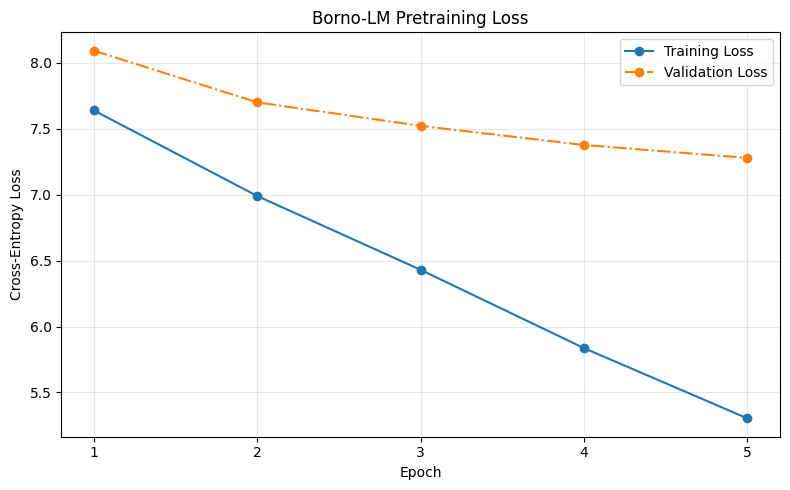

In [29]:
# Plot training loss and validation loss for each epochs
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(train_losses, val_losses):
    epochs_seen = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_seen, train_losses, marker="o", label="Training Loss")
    plt.plot(
        epochs_seen,
        val_losses,
        marker="o",
        linestyle="-.",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Borno-LM Pretraining Loss")
    plt.xticks(epochs_seen)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(CHECKPOINT_DIR / "loss-plot.png", dpi=150)
    plt.show()


plot_losses(train_losses, val_losses)

In [30]:
# Generate Bangla text from the pretrained Borno-LM.
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=100,
    context_size=512,
):

    model.eval()

    idx = tokenizer.encode_tensor(
        prompt,
        device=device,
    )

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -context_size:]

        logits = model(idx_cond)
        logits = logits[:, -1, :]

        idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)

    return tokenizer.decode_tensor(idx)


print(
    generate_text(
        model,
        "বাংলাদেশের নদীগুলো",
        max_new_tokens=25,
    )
)

বাংলাদেশের নদীগুলো, এবং অন্যান্য অংশ। এই অঞ্চলের মধ্যে রয়েছে, এবং অন্যান্য ভাষা এবং অন্যান্য ভাষা এবং অন্যান্য অংশ। এই ধরনের ভাষা এবং অন্যান্য
